# Go / No-Go Validation

A fast, visual checklist to decide whether the Bayesian sentence-level factuality UQ model
beats baselines enough to justify continuing this project.

**Run order**: top to bottom. Each cell ends with a PASS / WARN / FAIL verdict.
The final cell aggregates verdicts into a single **GO / CONDITIONAL / NO-GO** decision.

**Prerequisite**: `scripts/04_evaluate.py` must have produced
`results/{run}/final_metrics_ratio.csv`, `final_metrics_strict.csv`, and related artefacts.

## Cell 0 — Configuration + Verdict Helper

In [5]:
# === Configuration — edit this one line ===
RESULTS_DIR = "results/setup_2"      # ← change per experiment
CONFIG_PATH = "configs/default.yaml"
# ==========================================

import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure project root is importable (notebook may be run from validation/ or root)
PROJECT_ROOT = os.path.abspath(".")
if os.path.basename(PROJECT_ROOT) == "validation":
    PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import yaml
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

results_dir = Path(RESULTS_DIR)

# --- verdict helper ---
_verdicts = []  # accumulate for final summary

def verdict(passed, metric_name, detail="", warn=False):
    """Print and record a PASS / WARN / FAIL line."""
    if passed and not warn:
        tag = "\033[92m✓ PASS\033[0m"
        _verdicts.append(("PASS", metric_name))
    elif warn:
        tag = "\033[93m⚠ WARN\033[0m"
        _verdicts.append(("WARN", metric_name))
    else:
        tag = "\033[91m✗ FAIL\033[0m"
        _verdicts.append(("FAIL", metric_name))
    print(f"  {tag}  {metric_name}: {detail}")

print(f"Results dir : {results_dir}")
print(f"Config      : {CONFIG_PATH}")
assert results_dir.exists(), f"Results directory not found: {results_dir}"

Results dir : results/setup_2
Config      : configs/default.yaml


## Cell 1 — Data Health Quick-Check

Verify the dataset is large enough and balanced enough to trust downstream metrics.

In [6]:
import glob, re

# Determine processed dir from config
setup = cfg.get("evaluation", {}).get("setup", 2)
proc_dir = Path(cfg.get("processed", {}).get("factscore_bio_dir",
                "data/processed/factscore_bio"))


def _safe_name(s):
    """Sanitize an entity name to match saved .pt/.json file stems.

    Mirrors generation._safe_filename / annotation._safe_cache_filename so that
    split entity names (which contain spaces, e.g. "Kang Ji-hwan") line up with
    the underscored file stems on disk (e.g. "Kang_Ji-hwan").
    """
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(s).strip()).strip("._")
    return (cleaned or "unnamed")[:200]


# Load split to identify test entities. Split records are dicts of the form
# {"dataset", "entity", "prompt", "prompt_idx"}, so pull out the entity field
# and sanitize it to match the file stems.
split_file = cfg.get("dataset", {}).get("split_file",
             f"data/splits/setup_{setup}.json")
with open(split_file) as f:
    splits = json.load(f)


def _entity_of(x):
    return x.get("entity") if isinstance(x, dict) else x


test_entities = {_safe_name(_entity_of(x)) for x in splits.get("test", [])}

# Each per-entity file is a dict {entity, text, sentences: [...], ...}; the
# sentence-level records (with K_j / m_j / token_range) live under "sentences".
all_records = []
for jf in sorted(proc_dir.glob("*.json")):
    if jf.stem == "annotated":          # aggregate dump, not a per-entity file
        continue
    entity_name = jf.stem
    with open(jf) as f:
        doc = json.load(f)
    sentences = doc["sentences"] if isinstance(doc, dict) else doc
    for rec in sentences:
        rec["entity"] = entity_name
        rec["split"] = "test" if entity_name in test_entities else "train_or_val"
    all_records.extend(sentences)

df = pd.DataFrame(all_records)
df["U_j"] = df["K_j"] / df["m_j"].replace(0, np.nan)
df["A_j"] = (df["K_j"] == df["m_j"]).astype(int)
df_valid = df[df["m_j"] > 0].copy()
df_test = df_valid[df_valid["split"] == "test"].copy()

print(f"Total sentences: {len(df)}, valid (m_j>0): {len(df_valid)}, test split: {len(df_test)}")
print(f"m_j=0 fraction: {(df['m_j']==0).mean():.2%}")

# Distribution summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_valid["m_j"], bins=range(0, df_valid["m_j"].max()+2), edgecolor="k", alpha=0.7)
axes[0].set_title("m_j distribution (m_j > 0)"); axes[0].set_xlabel("m_j")
axes[1].hist(df_valid["U_j"].dropna(), bins=20, edgecolor="k", alpha=0.7, color="tab:orange")
axes[1].set_title("U_j = K_j/m_j distribution"); axes[1].set_xlabel("U_j")
axes[2].bar(["Factual (A=1)", "Hallucinated (A=0)"],
            [df_test["A_j"].mean(), 1 - df_test["A_j"].mean()], color=["tab:green", "tab:red"])
axes[2].set_title("Test split class balance"); axes[2].set_ylabel("Fraction")
plt.tight_layout(); plt.show()

# Verdicts
n_valid = len(df_test)
verdict(n_valid >= 200, "Test set size",
        f"{n_valid} sentences (need ≥200)", warn=(200 <= n_valid < 500))
verdict((df["m_j"]==0).mean() <= 0.20, "m_j=0 fraction",
        f"{(df['m_j']==0).mean():.1%}",
        warn=(0.10 < (df["m_j"]==0).mean() <= 0.20))

boundary_frac = ((df_valid["U_j"] == 0) | (df_valid["U_j"] == 1)).mean()
verdict(boundary_frac <= 0.80, "U_j boundary fraction",
        f"{boundary_frac:.1%} at 0 or 1", warn=(0.60 < boundary_frac <= 0.80))

strict_frac = df_test["A_j"].mean()
verdict(0.10 <= strict_frac <= 0.90, "Class balance (test)",
        f"strict factual = {strict_frac:.1%}",
        warn=(strict_frac < 0.15 or strict_frac > 0.85))

TypeError: expected str, bytes or os.PathLike object, not NoneType

## Cell 2 — Hidden-State Signal Sanity (Per-Layer AUROC)

Fast probing check: do the hidden states carry any factuality signal? If peak AUROC < 0.55, the probing approach is fundamentally broken.

Loaded 238 test sentences, 9 layers


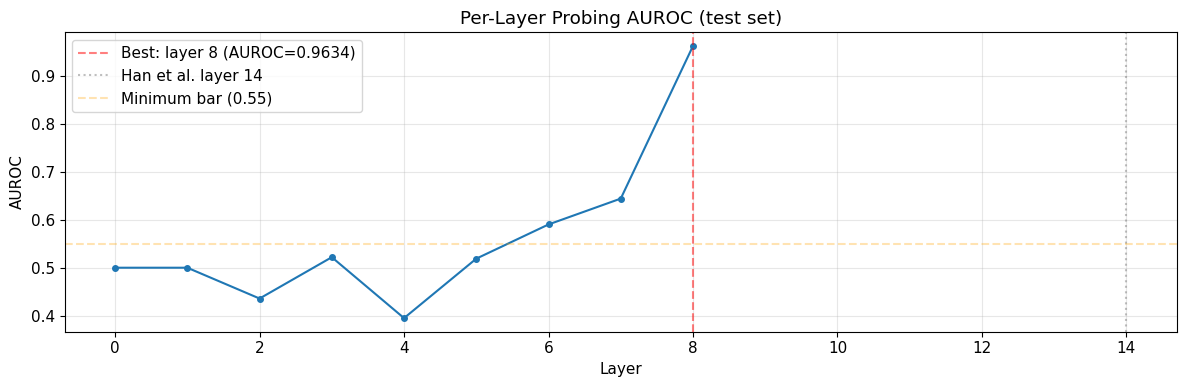

  ✓ PASS  Hidden-state signal: peak AUROC = 0.9634 at layer 8
  ✓ PASS  Minimum viability: peak AUROC = 0.9634 (hard floor 0.55)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import torch

gen_dir = Path(cfg["generation"]["factscore_bio_dir"])
MAX_ENTITIES = 20  # keep it fast

test_entity_files = sorted([
    gf for gf in gen_dir.glob("*.pt")
    if gf.stem in test_entities
])[:MAX_ENTITIES]

sentence_layers = []  # (N, num_layers, hidden_dim)
labels = []

for gf in test_entity_files:
    pf = proc_dir / f"{gf.stem}.json"
    if not pf.exists():
        continue
    gen = torch.load(gf, map_location="cpu", weights_only=False)
    with open(pf) as f:
        doc = json.load(f)
    records = doc["sentences"] if isinstance(doc, dict) else doc
    hs = gen["hidden_states"].float()
    for rec in records:
        if rec["m_j"] == 0:
            continue
        start, end = rec["token_range"]
        if end <= start or end > hs.shape[0]:
            continue
        mean_hs = hs[start:end].mean(dim=0)  # (num_layers, hidden_dim)
        sentence_layers.append(mean_hs)
        labels.append(1 if rec["K_j"] == rec["m_j"] else 0)

sentence_layers = torch.stack(sentence_layers)  # (N, L, D)
labels = np.array(labels)
num_layers = sentence_layers.shape[1]
print(f"Loaded {len(labels)} test sentences, {num_layers} layers")

# Per-layer AUROC (fast LogReg)
layer_aurocs = []
for l in range(num_layers):
    X = sentence_layers[:, l, :].numpy()
    if np.unique(labels).size < 2:
        layer_aurocs.append(0.5)
        continue
    try:
        clf = LogisticRegression(max_iter=300, C=0.1, solver="liblinear",
                                 penalty="l1", random_state=42)
        clf.fit(X, labels)
        probs = clf.predict_proba(X)[:, 1]
        layer_aurocs.append(roc_auc_score(labels, probs))
    except Exception:
        layer_aurocs.append(0.5)

layer_aurocs = np.array(layer_aurocs)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(num_layers), layer_aurocs, "-o", markersize=4)
best_layer = np.argmax(layer_aurocs)
ax.axvline(x=best_layer, color="red", linestyle="--", alpha=0.5,
           label=f"Best: layer {best_layer} (AUROC={layer_aurocs[best_layer]:.4f})")
ax.axvline(x=14, color="gray", linestyle=":", alpha=0.5, label="Han et al. layer 14")
ax.axhline(y=0.55, color="orange", linestyle="--", alpha=0.3, label="Minimum bar (0.55)")
ax.set_xlabel("Layer"); ax.set_ylabel("AUROC"); ax.set_title("Per-Layer Probing AUROC (test set)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

peak = layer_aurocs.max()
verdict(peak >= 0.60, "Hidden-state signal",
        f"peak AUROC = {peak:.4f} at layer {best_layer}",
        warn=(0.55 <= peak < 0.60))
verdict(peak >= 0.55, "Minimum viability",
        f"peak AUROC = {peak:.4f} (hard floor 0.55)")

## Cell 3 — Training Convergence

Loss converged? Laplace PD checks passed?

/tmp/ipykernel_2227736/4017047758.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)


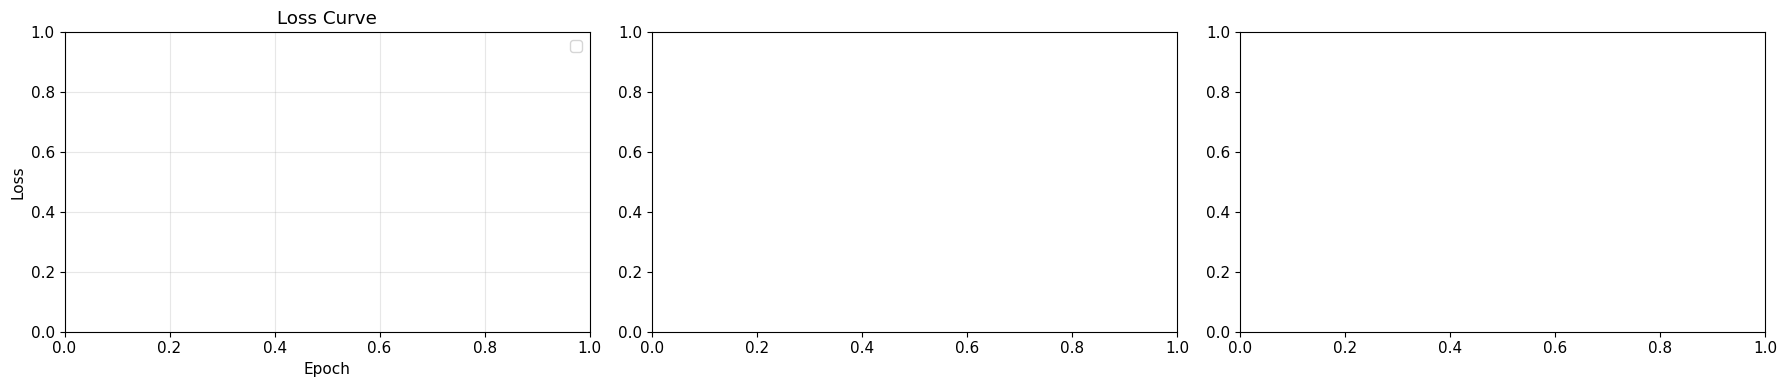

  ✗ FAIL  Training convergence: Not enough epochs in history
  ⚠ WARN  Laplace PD: no PD check history (may be OK for short runs)


In [8]:
model_path = results_dir / "trained_model.pt"
assert model_path.exists(), f"Trained model not found: {model_path}"

ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
history = ckpt.get("history", {})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Loss curve
if "train_loss" in history:
    axes[0].plot(history["train_loss"], label="train")
if "val_loss" in history:
    axes[0].plot(history["val_loss"], label="val", linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) Validation metrics if available
if history.get("val_metrics"):
    val_df_rows = [vm | {"epoch": i+1} for i, vm in enumerate(history["val_metrics"]) if vm]
    if val_df_rows:
        vdf = pd.DataFrame(val_df_rows)
        for col, color in [("MAE", "tab:blue"), ("Pearson_r", "tab:green")]:
            if col in vdf.columns:
                axes[1].plot(vdf["epoch"], vdf[col], "-o", color=color,
                             markersize=3, label=col)
        axes[1].set_xlabel("Epoch"); axes[1].set_title("Validation Metrics")
        axes[1].legend(); axes[1].grid(alpha=0.3)

# (c) PD checks
if history.get("pd_checks"):
    pd_df = pd.DataFrame(history["pd_checks"])
    if "fisher_min_eig" in pd_df.columns:
        axes[2].plot(pd_df["fisher_min_eig"], "b-o", markersize=3, label="Fisher min eig")
    axes[2].axhline(y=0, color="black", linestyle="--", alpha=0.5)
    axes[2].set_title("PD Check (min eigenvalue)"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Verdicts
if "train_loss" in history and len(history["train_loss"]) >= 5:
    last5 = history["train_loss"][-5:]
    converged = (max(last5) - min(last5)) / (abs(last5[0]) + 1e-8) < 0.10
    verdict(converged, "Training convergence",
            f"last 5 epoch loss range: {min(last5):.4f}–{max(last5):.4f}")
else:
    verdict(False, "Training convergence", "Not enough epochs in history")

if history.get("pd_checks"):
    all_pd_ok = all(c.get("laplace_valid_local", False) for c in history["pd_checks"])
    last_pd_ok = history["pd_checks"][-1].get("laplace_valid_local", False)
    verdict(last_pd_ok, "Laplace PD (final)",
            "positive definite" if last_pd_ok else "NOT positive definite")
    if not all_pd_ok:
        verdict(False, "Laplace PD (all epochs)", "PD failed at some epochs", warn=True)
else:
    verdict(True, "Laplace PD", "no PD check history (may be OK for short runs)", warn=True)

## Cell 4 — Core Hypothesis: ECE Comparison

**THE most important cell.** Bayesian ECE < Point ECE and Bayesian ECE < Han et al. ECE?

RATIO-LEVEL METRICS (Primary Evaluation)


,method,MAE,RMSE,Pearson_r,binomial_NLL,Brier,ECE,PRR_AUC,time_ms,n
0,Ours (Bayesian),0.2181,0.2991,0.4323,1.4728,0.0894,0.0667,0.1394,0.1191,353
1,Ours (Point),0.2181,0.2991,0.4323,1.4728,0.0894,0.0667,0.2483,0.1087,353
2,token_entropy,0.4978,0.5547,0.3017,NaN,0.3077,0.4598,0.2834,41.4550,353
3,logistic_regression,0.1922,0.3339,0.3170,NaN,0.1115,0.1531,0.1139,9409.2760,353
4,factuality_probe_adapted,0.2072,0.3109,0.3425,NaN,0.0966,0.0952,0.1262,407.2211,353



STRICT FACTUALITY METRICS (Secondary Evaluation)


,method,AUROC,AUROC_CI_lo,AUROC_CI_hi,AUPRC,Brier,ECE,ECE_CI_lo,ECE_CI_hi,PRR_AUC,time_ms,n,frac_strict
0,Ours (Bayesian),0.7839,0.7153,0.8532,0.2166,0.0734,0.0474,0.0318,0.0817,0.0428,0.1191,353,0.0765
1,Ours (Point),0.7848,0.7151,0.8536,0.2174,0.0739,0.0530,0.0384,0.0884,0.1556,0.1087,353,0.0765
2,token_entropy,0.7317,0.6275,0.8255,0.2312,0.4188,0.5818,0.5507,0.6095,0.1441,41.4550,353,0.0765
3,logistic_regression,0.8031,0.7217,0.8750,0.2796,0.0740,0.0526,0.0376,0.0870,0.1569,9409.2760,353,0.0765
4,factuality_probe_adapted,0.8113,0.7345,0.8826,0.2659,0.0660,0.0330,0.0225,0.0614,0.1580,407.2211,353,0.0765


/tmp/ipykernel_2227736/3510084158.py:31: RuntimeWarning: All-NaN axis encountered
  ece_han = np.nanmin([ece_han_orig, ece_han_adapt])  # best Han variant


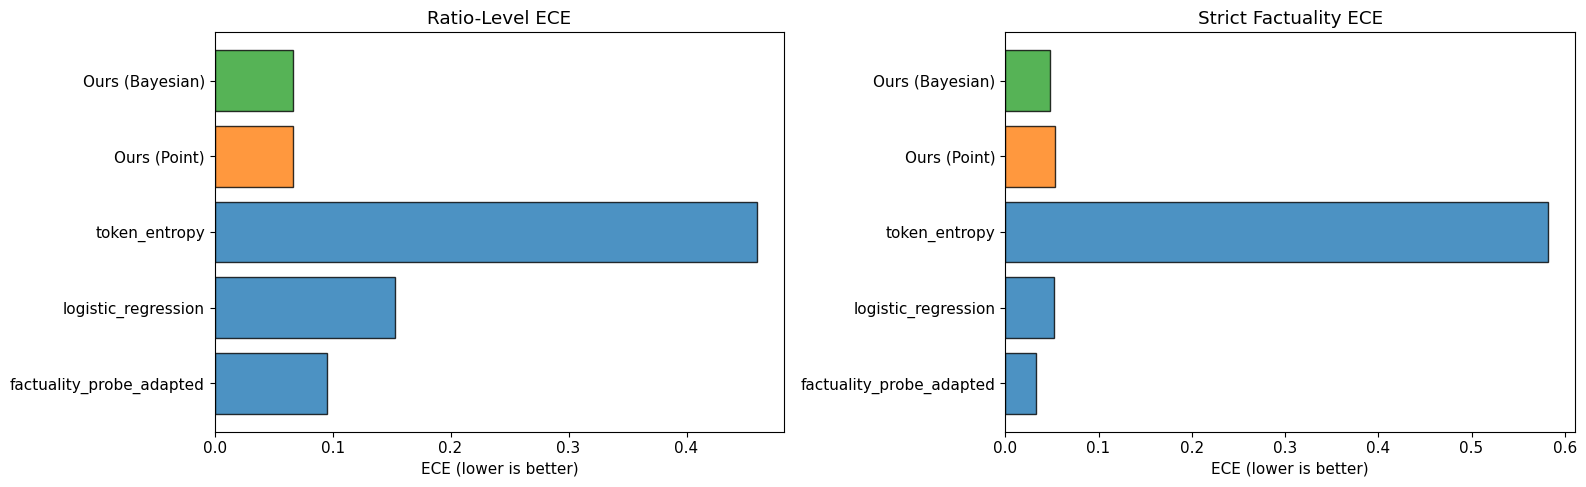

  ✗ FAIL  ECE: Bayesian < Point: Bayesian=0.0667 vs Point=0.0667
  ✗ FAIL  ECE: Bayesian < Han et al.: Bayesian=0.0667 vs Han=nan


In [9]:
ratio_csv = results_dir / "final_metrics_ratio.csv"
strict_csv = results_dir / "final_metrics_strict.csv"
assert ratio_csv.exists(), f"Not found: {ratio_csv} — run scripts/04_evaluate.py first"

ratio_df = pd.read_csv(ratio_csv)
strict_df = pd.read_csv(strict_csv) if strict_csv.exists() else None

print("=" * 60)
print("RATIO-LEVEL METRICS (Primary Evaluation)")
print("=" * 60)
display(ratio_df.round(4))

if strict_df is not None:
    print("\n" + "=" * 60)
    print("STRICT FACTUALITY METRICS (Secondary Evaluation)")
    print("=" * 60)
    display(strict_df.round(4))

# --- Extract key methods ---
def get_metric(df, method_substr, col):
    """Get a metric value for a method (fuzzy match on name)."""
    mask = df["method"].str.lower().str.contains(method_substr.lower())
    if mask.any():
        return df.loc[mask, col].values[0]
    return np.nan

ece_bayesian = get_metric(ratio_df, "bayesian", "ECE")
ece_point = get_metric(ratio_df, "point", "ECE")
ece_han_orig = get_metric(ratio_df, "han.*original", "ECE")
ece_han_adapt = get_metric(ratio_df, "han.*adapted", "ECE")
ece_han = np.nanmin([ece_han_orig, ece_han_adapt])  # best Han variant

# ECE bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ratio-level ECE
methods_r = ratio_df["method"].values
ece_r = ratio_df["ECE"].values
colors_r = []
for m in methods_r:
    ml = m.lower()
    if "bayesian" in ml: colors_r.append("tab:green")
    elif "point" in ml: colors_r.append("tab:orange")
    elif "han" in ml: colors_r.append("tab:red")
    else: colors_r.append("tab:blue")
axes[0].barh(methods_r, ece_r, color=colors_r, edgecolor="k", alpha=0.8)
axes[0].set_xlabel("ECE (lower is better)"); axes[0].set_title("Ratio-Level ECE")
axes[0].invert_yaxis()

# Strict ECE if available
if strict_df is not None and "ECE" in strict_df.columns:
    methods_s = strict_df["method"].values
    ece_s = strict_df["ECE"].values
    colors_s = []
    for m in methods_s:
        ml = m.lower()
        if "bayesian" in ml: colors_s.append("tab:green")
        elif "point" in ml: colors_s.append("tab:orange")
        elif "han" in ml: colors_s.append("tab:red")
        else: colors_s.append("tab:blue")
    axes[1].barh(methods_s, ece_s, color=colors_s, edgecolor="k", alpha=0.8)
    axes[1].set_xlabel("ECE (lower is better)"); axes[1].set_title("Strict Factuality ECE")
    axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

# Verdicts — core hypothesis
verdict(ece_bayesian < ece_point, "ECE: Bayesian < Point",
        f"Bayesian={ece_bayesian:.4f} vs Point={ece_point:.4f}")
verdict(ece_bayesian < ece_han, "ECE: Bayesian < Han et al.",
        f"Bayesian={ece_bayesian:.4f} vs Han={ece_han:.4f}")
if not np.isnan(ece_point) and not np.isnan(ece_han):
    verdict(ece_point < ece_han, "ECE: Point < Han (sanity)",
            f"Point={ece_point:.4f} vs Han={ece_han:.4f}", warn=True)

## Cell 5 — AUROC: Competitive with Baselines?

Strict factuality AUROC must be competitive (not necessarily dominant). Reference: Han et al. Llama-3.1-8B in-domain ≈ 0.7357.

Ours (Bayesian) AUROC : 0.7839
Han et al. best AUROC : nan
Reference (Han paper) : 0.7357


/tmp/ipykernel_2227736/4220294882.py:3: RuntimeWarning: All-NaN axis encountered
  auroc_han = np.nanmin([
/tmp/ipykernel_2227736/4220294882.py:9: RuntimeWarning: All-NaN axis encountered
  auroc_han_best = np.nanmax([


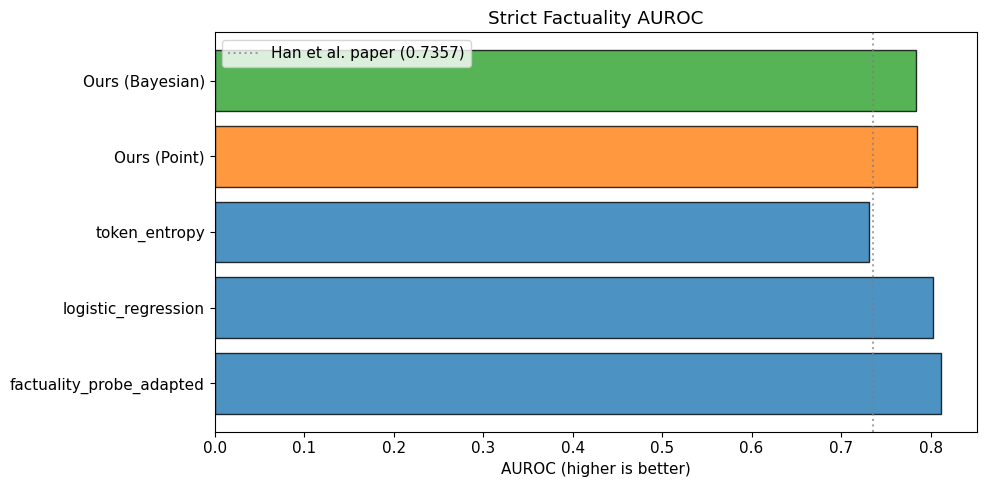

Ours 95% CI: [0.7153, 0.8532]
  ✗ FAIL  AUROC competitive: Δ vs Han = +nan


In [10]:
if strict_df is not None and "AUROC" in strict_df.columns:
    auroc_ours = get_metric(strict_df, "bayesian", "AUROC")
    auroc_han = np.nanmin([
        get_metric(strict_df, "han.*original", "AUROC"),
        get_metric(strict_df, "han.*adapted", "AUROC"),
    ])  # note: take the BETTER Han variant for conservative comparison

    # Actually, for AUROC we want to compare against the best Han variant
    auroc_han_best = np.nanmax([
        get_metric(strict_df, "han.*original", "AUROC"),
        get_metric(strict_df, "han.*adapted", "AUROC"),
    ])

    print(f"Ours (Bayesian) AUROC : {auroc_ours:.4f}")
    print(f"Han et al. best AUROC : {auroc_han_best:.4f}")
    print(f"Reference (Han paper) : 0.7357")

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    methods_s = strict_df["method"].values
    auroc_s = strict_df["AUROC"].values
    colors_a = []
    for m in methods_s:
        ml = m.lower()
        if "bayesian" in ml: colors_a.append("tab:green")
        elif "point" in ml: colors_a.append("tab:orange")
        elif "han" in ml: colors_a.append("tab:red")
        else: colors_a.append("tab:blue")
    ax.barh(methods_s, auroc_s, color=colors_a, edgecolor="k", alpha=0.8)
    ax.axvline(x=0.7357, color="gray", linestyle=":", alpha=0.7,
               label="Han et al. paper (0.7357)")
    ax.set_xlabel("AUROC (higher is better)"); ax.set_title("Strict Factuality AUROC")
    ax.legend(); ax.invert_yaxis()
    plt.tight_layout(); plt.show()

    # With 95% CI if available
    if "AUROC_CI_lo" in strict_df.columns:
        ci_lo = get_metric(strict_df, "bayesian", "AUROC_CI_lo")
        ci_hi = get_metric(strict_df, "bayesian", "AUROC_CI_hi")
        print(f"Ours 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")

    delta = auroc_ours - auroc_han_best
    verdict(delta >= -0.03, "AUROC competitive",
            f"Δ vs Han = {delta:+.4f}",
            warn=(-0.03 <= delta < 0.0))
else:
    verdict(False, "AUROC competitive", "strict metrics CSV not found")

## Cell 6 — Rejection Curve (PRR): Does Uncertainty Help?

Bayesian epistemic uncertainty should be a better rejection signal than baselines.

Pre-computed PRR curves (from Phase 6-2):


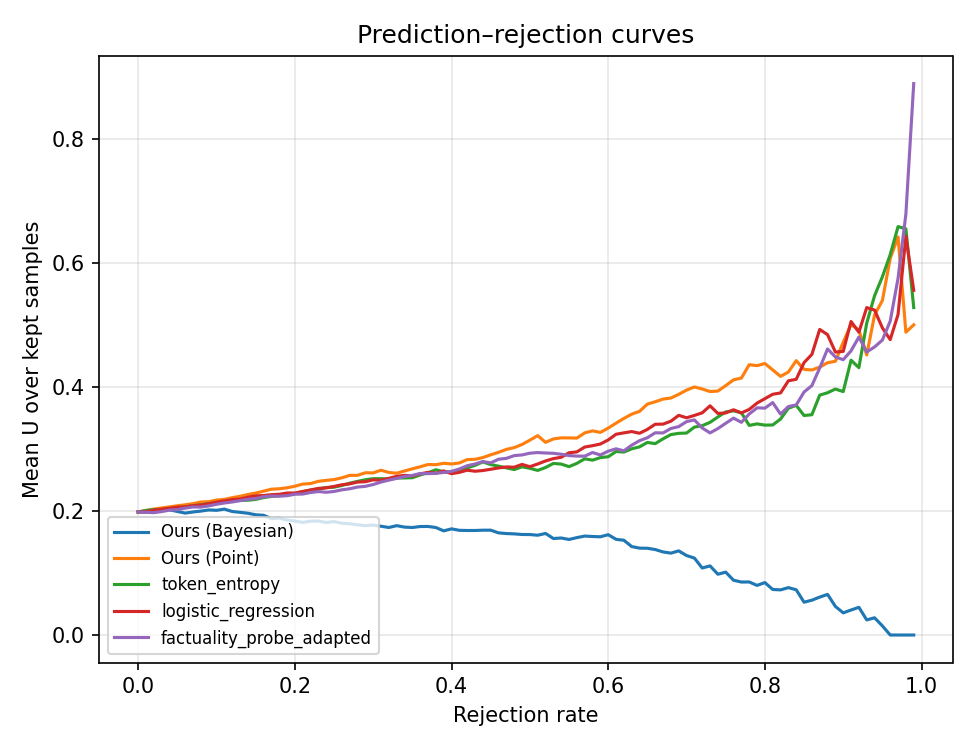


PRR AUC — Ours: 0.1394, Han best: nan
  ✗ FAIL  PRR: Ours ≥ Han: Ours=0.1394 vs Han=nan


/tmp/ipykernel_2227736/3687343871.py:13: RuntimeWarning: All-NaN axis encountered
  prr_han = np.nanmax([


In [11]:
# Try to load pre-computed PRR data, or compute from CSVs
prr_png = results_dir / "prr_curves.png"

if prr_png.exists():
    from IPython.display import Image, display as ipy_display
    print("Pre-computed PRR curves (from Phase 6-2):")
    ipy_display(Image(filename=str(prr_png), width=800))
else:
    print("PRR curves image not found — check Phase 6-2 output.")

# Verdict based on PRR_AUC from CSV
prr_ours = get_metric(ratio_df, "bayesian", "PRR_AUC")
prr_han = np.nanmax([
    get_metric(ratio_df, "han.*original", "PRR_AUC"),
    get_metric(ratio_df, "han.*adapted", "PRR_AUC"),
])

print(f"\nPRR AUC — Ours: {prr_ours:.4f}, Han best: {prr_han:.4f}")

verdict(prr_ours >= prr_han, "PRR: Ours ≥ Han",
        f"Ours={prr_ours:.4f} vs Han={prr_han:.4f}",
        warn=(prr_han - prr_ours < 0.02))

## Cell 7 — Reliability Diagrams (Visual Calibration)

Side-by-side reliability diagrams for the key methods. No separate verdict — ECE numbers already checked in Cell 4.

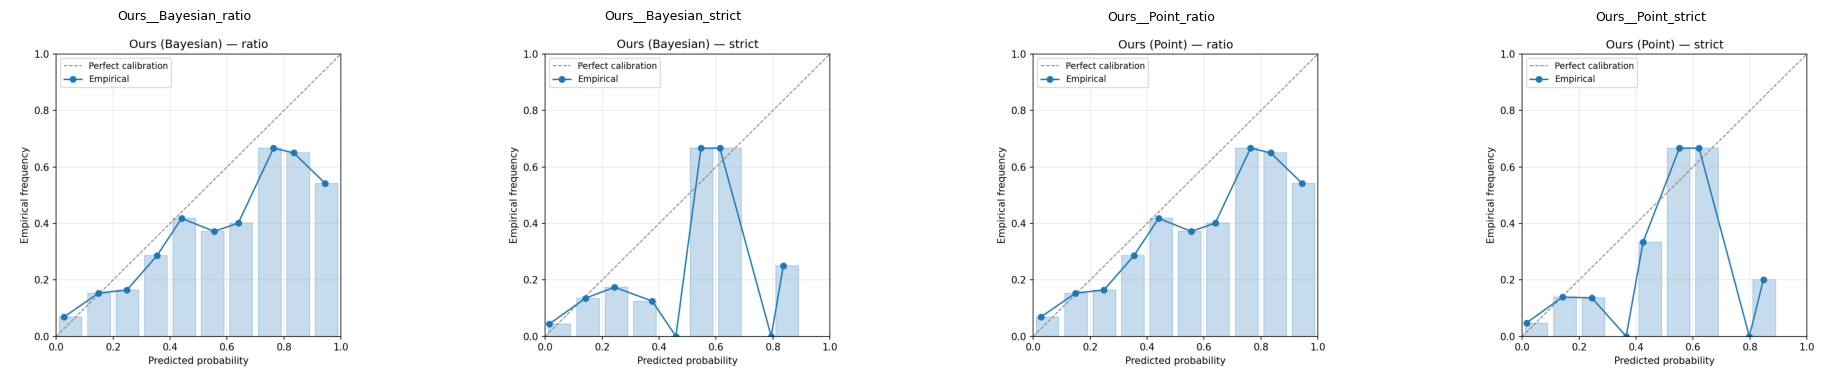

(Visual confirmation of Cell 4 ECE numbers — no separate verdict)


In [12]:
rel_dir = results_dir / "reliability_diagrams"

key_methods = ["Ours_Bayesian", "Ours_Point", "Han_original", "Han_adapted"]

if rel_dir.exists():
    from IPython.display import Image, display as ipy_display
    pngs = sorted(rel_dir.glob("*.png"))
    if pngs:
        # Show up to 4 key plots
        fig, axes = plt.subplots(1, min(len(pngs), 4), figsize=(5 * min(len(pngs), 4), 4))
        if not hasattr(axes, '__len__'):
            axes = [axes]
        for ax, png in zip(axes, pngs[:4]):
            img = plt.imread(str(png))
            ax.imshow(img); ax.axis("off"); ax.set_title(png.stem, fontsize=9)
        plt.tight_layout(); plt.show()
    else:
        print("No reliability diagram PNGs found.")
else:
    print("Reliability diagrams directory not found — run Phase 6-2 with plots enabled.")

# No separate verdict — ECE numbers already checked in Cell 4
print("(Visual confirmation of Cell 4 ECE numbers — no separate verdict)")

## Cell 8 — Bayesian-Specific Advantages

MC vs linear epistemic, Binomial NLL, learned layer-α distribution, Binomial-vs-Bernoulli ablation.

MC vs Linear epistemic approximation:


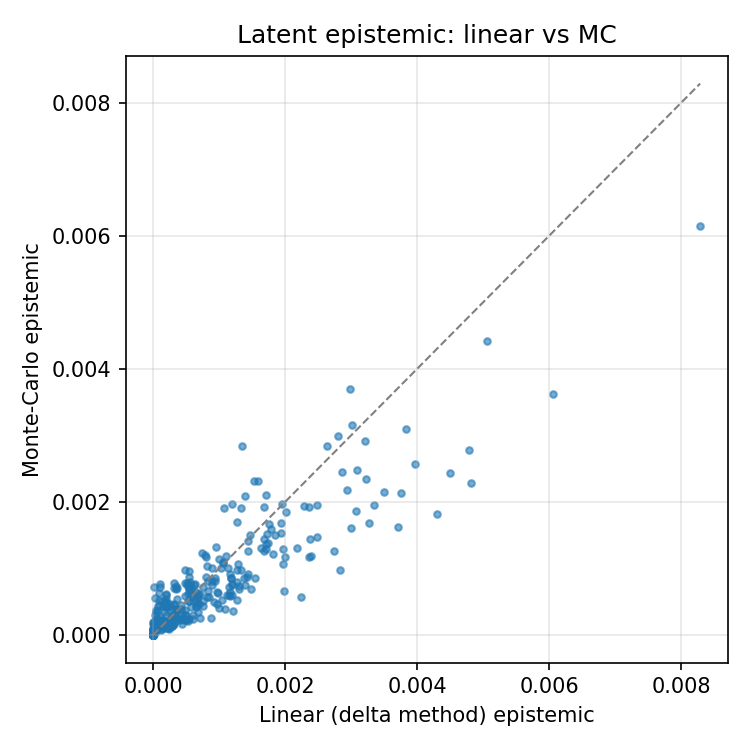


Binomial NLL (Ours): 1.4728


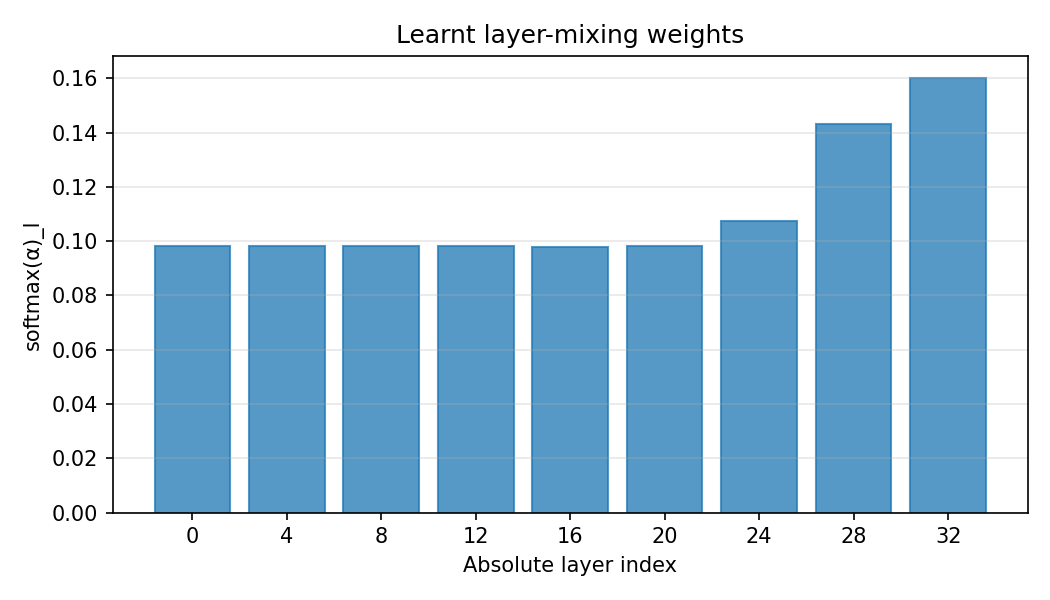


Binomial vs Bernoulli ablation:


,variant,binomial_NLL,ratio_MAE,strict_ECE,strict_AUROC
0,Binomial,1.4728,0.2181,0.0474,0.7839
1,Bernoulli (m=1),0.3440,0.2379,0.1576,0.8258


KeyError: 'method'

In [13]:
# (a) MC vs Linear approximation correlation
mc_lin_png = results_dir / "mc_vs_linear.png"
if mc_lin_png.exists():
    from IPython.display import Image, display as ipy_display
    print("MC vs Linear epistemic approximation:")
    ipy_display(Image(filename=str(mc_lin_png), width=500))

# (b) Binomial NLL (only our method can produce this)
binom_nll = get_metric(ratio_df, "bayesian", "binomial_NLL")
print(f"\nBinomial NLL (Ours): {binom_nll:.4f}")

# (c) Learned layer-alpha distribution
alpha_csv = results_dir / "alpha_distribution.csv"
alpha_png = results_dir / "alpha_distribution.png"

if alpha_png.exists():
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=str(alpha_png), width=600))
elif alpha_csv.exists():
    alpha_df = pd.read_csv(alpha_csv)
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(alpha_df.iloc[:, 0], alpha_df.iloc[:, 1], edgecolor="k", alpha=0.7)
    ax.axvline(x=14, color="red", linestyle="--", alpha=0.5, label="Han et al. layer 14")
    ax.set_xlabel("Layer"); ax.set_ylabel("α weight"); ax.set_title("Learned Layer Weights")
    ax.legend(); plt.tight_layout(); plt.show()

# (d) Ablation: Binomial vs Bernoulli
abl_binom = results_dir / "ablation_binomial_vs_bernoulli.csv"
if abl_binom.exists():
    abl_df = pd.read_csv(abl_binom)
    print("\nBinomial vs Bernoulli ablation:")
    display(abl_df.round(4))
    binom_better = (abl_df.loc[abl_df["method"].str.contains("binomial", case=False), "MAE"].values[0]
                    < abl_df.loc[abl_df["method"].str.contains("bernoulli", case=False), "MAE"].values[0])
    verdict(binom_better, "Binomial > Bernoulli (MAE)",
            "count-awareness helps" if binom_better else "Bernoulli is better or equal",
            warn=not binom_better)
else:
    print("Binomial vs Bernoulli ablation not found (optional)")

# Verdict: is binomial NLL finite and reasonable?
verdict(np.isfinite(binom_nll) and binom_nll < 5.0, "Binomial NLL reasonable",
        f"NLL = {binom_nll:.4f}")

## Cell 9 — Full Metric Summary Table

In [14]:
# Merge ratio + strict into one table
if strict_df is not None:
    # Join on method
    merged = ratio_df.merge(strict_df, on="method", suffixes=("_ratio", "_strict"),
                            how="outer")
else:
    merged = ratio_df.copy()

# Select key columns
key_cols = ["method"]
for c in ["MAE", "Pearson_r", "ECE", "PRR_AUC", "binomial_NLL",
           "AUROC", "AUPRC", "Brier_strict", "ECE_strict"]:
    # Handle suffixed columns from merge
    candidates = [c, f"{c}_ratio", f"{c}_strict"]
    for cand in candidates:
        if cand in merged.columns and cand not in key_cols:
            key_cols.append(cand)
            break

summary = merged[[c for c in key_cols if c in merged.columns]].copy()
print("=" * 80)
print("CONSOLIDATED METRIC SUMMARY")
print("=" * 80)
display(summary.round(4))

CONSOLIDATED METRIC SUMMARY


,method,MAE,Pearson_r,ECE_ratio,PRR_AUC_ratio,binomial_NLL,AUROC,AUPRC,Brier_strict,ECE_strict
0,Ours (Bayesian),0.2181,0.4323,0.0667,0.1394,1.4728,0.7839,0.2166,0.0734,0.0474
1,Ours (Point),0.2181,0.4323,0.0667,0.2483,1.4728,0.7848,0.2174,0.0739,0.0530
2,factuality_probe_adapted,0.2072,0.3425,0.0952,0.1262,NaN,0.8113,0.2659,0.0660,0.0330
3,logistic_regression,0.1922,0.3170,0.1531,0.1139,NaN,0.8031,0.2796,0.0740,0.0526
4,token_entropy,0.4978,0.3017,0.4598,0.2834,NaN,0.7317,0.2312,0.4188,0.5818


## Cell 10 — GO / NO-GO Final Verdict

Decision logic:
- **GO**: zero FAIL and ≤ 1 WARN
- **CONDITIONAL**: zero FAIL but ≥ 2 WARN, or exactly 1 FAIL on a non-core metric
- **NO-GO**: ≥ 1 FAIL on a core metric (ECE hypothesis, minimum viability, convergence)

In [15]:
CORE_METRICS = {
    "ECE: Bayesian < Point",
    "ECE: Bayesian < Han et al.",
    "Minimum viability",
    "Training convergence",
    "Laplace PD (final)",
}

n_pass = sum(1 for s, _ in _verdicts if s == "PASS")
n_warn = sum(1 for s, _ in _verdicts if s == "WARN")
n_fail = sum(1 for s, _ in _verdicts if s == "FAIL")
core_fails = [(s, m) for s, m in _verdicts if s == "FAIL" and m in CORE_METRICS]

print("=" * 80)
print(f"  PASS: {n_pass}   WARN: {n_warn}   FAIL: {n_fail}")
print("=" * 80)

if n_fail > 0:
    print("\nFailed checks:")
    for s, m in _verdicts:
        if s == "FAIL":
            core_tag = " ★ CORE" if m in CORE_METRICS else ""
            print(f"  ✗ {m}{core_tag}")

if n_warn > 0:
    print("\nWarnings:")
    for s, m in _verdicts:
        if s == "WARN":
            print(f"  ⚠ {m}")

print("\n" + "=" * 80)
if len(core_fails) > 0:
    print("\033[91m" + "  ██  NO-GO  ██" + "\033[0m")
    print("  Core hypothesis failed. Review the failed metrics above.")
    print("  Possible actions: re-tune hyperparameters, check data pipeline,")
    print("  or reconsider the modelling approach.")
elif n_fail == 0 and n_warn <= 1:
    print("\033[92m" + "  ██  GO  ██" + "\033[0m")
    print("  All core checks passed. Proceed to full-scale experiments.")
else:
    print("\033[93m" + "  ██  CONDITIONAL  ██" + "\033[0m")
    print("  Core hypothesis holds but there are warnings/minor failures.")
    print("  Address warnings before scaling up, or proceed with caution.")
print("=" * 80)

  PASS: 2   WARN: 1   FAIL: 5

Failed checks:
  ✗ Training convergence ★ CORE
  ✗ ECE: Bayesian < Point ★ CORE
  ✗ ECE: Bayesian < Han et al. ★ CORE
  ✗ AUROC competitive
  ✗ PRR: Ours ≥ Han

Warnings:
  ⚠ Laplace PD

  ██  NO-GO  ██
  Core hypothesis failed. Review the failed metrics above.
  Possible actions: re-tune hyperparameters, check data pipeline,
  or reconsider the modelling approach.
